<a href="https://colab.research.google.com/github/samrat-rm/Brain-Cache/blob/main/LoanTap_Logistic_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LoanTap Logistic Regression


**(A Scaler Business case study)**

Date: 9 June 2026

### Context:

LoanTap is an online platform committed to delivering customized loan products to millennials. They innovate in an otherwise dull loan segment, to deliver instant, flexible loans on consumer friendly terms to salaried professionals and businessmen.

The data science team at LoanTap is building an underwriting layer to determine the creditworthiness of MSMEs as well as individuals.

LoanTap deploys formal credit to salaried individuals and businesses 4 main financial instruments:

- Personal Loan
- EMI Free Loan
- Personal Overdraft
- Advance Salary Loan


This case study will focus on the underwriting process behind Personal Loan only.



### Problem Statement:

Given a set of attributes for an Individual, determine if a credit line should be extended to them. If so, what should the repayment terms be in business recommendations?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
url = "https://raw.githubusercontent.com/samrat-rm/Brain-Cache/main/Business_case_study/Data/LoanTap.csv"
df = pd.read_csv(url)
df.head()

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,...,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,application_type,mort_acc,pub_rec_bankruptcies,address
0,10000.0,36 months,11.44,329.48,B,B4,Marketing,10+ years,RENT,117000.0,...,16.0,0.0,36369.0,41.8,25.0,w,INDIVIDUAL,0.0,0.0,"0174 Michelle Gateway\r\nMendozaberg, OK 22690"
1,8000.0,36 months,11.99,265.68,B,B5,Credit analyst,4 years,MORTGAGE,65000.0,...,17.0,0.0,20131.0,53.3,27.0,f,INDIVIDUAL,3.0,0.0,"1076 Carney Fort Apt. 347\r\nLoganmouth, SD 05113"
2,15600.0,36 months,10.49,506.97,B,B3,Statistician,< 1 year,RENT,43057.0,...,13.0,0.0,11987.0,92.2,26.0,f,INDIVIDUAL,0.0,0.0,"87025 Mark Dale Apt. 269\r\nNew Sabrina, WV 05113"
3,7200.0,36 months,6.49,220.65,A,A2,Client Advocate,6 years,RENT,54000.0,...,6.0,0.0,5472.0,21.5,13.0,f,INDIVIDUAL,0.0,0.0,"823 Reid Ford\r\nDelacruzside, MA 00813"
4,24375.0,60 months,17.27,609.33,C,C5,Destiny Management Inc.,9 years,MORTGAGE,55000.0,...,13.0,0.0,24584.0,69.8,43.0,f,INDIVIDUAL,1.0,0.0,"679 Luna Roads\r\nGreggshire, VA 11650"


## Understanding the data

In this section we try to understand the domain specific terms and metrics.

We understand each column , the meaning of each category and the formula used to calculate ratios. This will be helpful during data cleaning, feature engiennering and EDA.




In [3]:
df.shape

(396030, 27)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 396030 entries, 0 to 396029
Data columns (total 27 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   loan_amnt             396030 non-null  float64
 1   term                  396030 non-null  object 
 2   int_rate              396030 non-null  float64
 3   installment           396030 non-null  float64
 4   grade                 396030 non-null  object 
 5   sub_grade             396030 non-null  object 
 6   emp_title             373103 non-null  object 
 7   emp_length            377729 non-null  object 
 8   home_ownership        396030 non-null  object 
 9   annual_inc            396030 non-null  float64
 10  verification_status   396030 non-null  object 
 11  issue_d               396030 non-null  object 
 12  loan_status           396030 non-null  object 
 13  purpose               396030 non-null  object 
 14  title                 394274 non-null  object 
 15  

### Categorical Data

In [5]:
df.select_dtypes(include='object').columns

Index(['term', 'grade', 'sub_grade', 'emp_title', 'emp_length',
       'home_ownership', 'verification_status', 'issue_d', 'loan_status',
       'purpose', 'title', 'earliest_cr_line', 'initial_list_status',
       'application_type', 'address'],
      dtype='object')

Now, Lets understand each column and each column's descrition.

**Data dictionary:**


- term : The number of payments on the loan. Values are in months and can be either 36 or 60.
- grade : LoanTap assigned loan grade
- sub_grade : LoanTap assigned loan subgrade
- emp_title :The job title supplied by the Borrower when applying for the loan.
- emp_length : Employment length in years. Possible values are between 0 and 10 where 0 means less than one year and 10 means ten or more years.
- home_ownership : The home ownership status provided by the borrower during registration or obtained from the credit report.
- verification_status : Indicates if income was verified by LoanTap, not verified, or if the income source was verified
- issue_d : The month which the loan was funded
- loan_status : Current status of the loan - Target Variable
- purpose : A category provided by the borrower for the loan request.
- title : The loan title provided by the borrower
- earliest_cr_line :The month the borrower's earliest reported
- initial_list_status : The initial listing status of the loan. Possible values are – W, F
- application_type : Indicates whether the loan is an individual application or a joint application with two co-borrowers
- Address: Address of the individual

In [6]:
df['term'].value_counts()

,count
term,
36 months,302005
60 months,94025


- ~76% people chose 36 month term and the rest chose 60 month term.

Each of the 6 grade has 5 sub grades. Eg: A1 - A5 , B1 - B5...

In [7]:
print('Unique values and their order for `grade` column:')
print(df['grade'].sort_values().unique())

print('\nUnique values and their order for `sub_grade` column:')
print(df['sub_grade'].sort_values().unique())

Unique values and their order for `grade` column:
['A' 'B' 'C' 'D' 'E' 'F' 'G']

Unique values and their order for `sub_grade` column:
['A1' 'A2' 'A3' 'A4' 'A5' 'B1' 'B2' 'B3' 'B4' 'B5' 'C1' 'C2' 'C3' 'C4'
 'C5' 'D1' 'D2' 'D3' 'D4' 'D5' 'E1' 'E2' 'E3' 'E4' 'E5' 'F1' 'F2' 'F3'
 'F4' 'F5' 'G1' 'G2' 'G3' 'G4' 'G5']


The `grade` column represents an internal credit rating assigned by LoanTap, where 'A' is the best (lowest risk) and 'G' is the worst (highest risk). Within each grade, `sub_grade` further refines this rating, with '1' being better than '5'. For example, A1 is superior to A5, and A is superior to B.

In [8]:
print(df['emp_title'].value_counts().head(20))
print(f'Number of unique employee titles: {df["emp_title"].nunique()}')

emp_title
Teacher                     4389
Manager                     4250
Registered Nurse            1856
RN                          1846
Supervisor                  1830
Sales                       1638
Project Manager             1505
Owner                       1410
Driver                      1339
Office Manager              1218
manager                     1145
Director                    1089
General Manager             1074
Engineer                     995
teacher                      962
driver                       882
Vice President               857
Operations Manager           763
Administrative Assistant     756
Accountant                   748
Name: count, dtype: int64
Number of unique employee titles: 173105


The `emp_title` column contains the job title provided by the borrower. With over 170,000 unique values, this column has very high cardinality, making it difficult to use directly in a machine learning model. However, it can be a valuable source for feature engineering.

Potential Feature Engineering Ideas:
- **Categorization**: Group similar job titles into broader categories (e.g., 'Teacher', 'Engineer', 'Medical Professional', 'Manager').
- **Keywords**: Extract keywords from job titles that might indicate seniority, industry, or specific skills.
- **Binary Features**: Create binary flags for certain high-frequency or high-impact job titles (e.g., `is_owner`, `is_doctor`).
- **Embedding**: For more advanced approaches, one could use text embeddings if a sufficient vocabulary of job titles is available.

For now, given its high cardinality, we will treat it as a column to be processed during feature engineering, rather than directly used as a categorical feature.

In [9]:
df['emp_length'].value_counts()

,count
emp_length,
10+ years,126041
2 years,35827
< 1 year,31725
3 years,31665
5 years,26495
1 year,25882
4 years,23952
6 years,20841
7 years,20819


- The emp_length column describes the borrower's employment length in years. The possible values range from 0 (meaning less than one year) to 10 (meaning ten or more years).
- Feature Engineerig: We can combine emp_years and job_title to extract or more confidently describe senior positions or skill level.

In [10]:
df['home_ownership'].value_counts()

,count
home_ownership,
MORTGAGE,198348
RENT,159790
OWN,37746
OTHER,112
NONE,31
ANY,3


- OTHER: This category typically refers to housing situations that don't fit into the standard categories like 'MORTGAGE', 'RENT', or 'OWN'. It could include living with relatives without paying rent, living in employer-provided housing, or other less common arrangements.
- NONE: This usually means the borrower does not own a home and is not renting. They might be living rent-free with family or friends, or in a transitional living situation.
- ANY: This is a less common category, but it could imply a broad or unspecified form of ownership, or it might be a catch-all for various non-standard situations.

In [11]:
df['verification_status'].value_counts()

,count
verification_status,
Verified,139563
Source Verified,131385
Not Verified,125082


- 'Source Verified' in the verification_status column means that LoanTap has confirmed the borrower's income or other financial information directly with a third-party source. This could include contacting the borrower's employer, bank, or another official institution to verify the provided details.

In [12]:
df['issue_d'].agg(['min','max'])

,issue_d
min,Apr-2008
max,Sep-2016


- The LoanTap consists of 8 years of loan data.  

In [13]:
df['loan_status'].value_counts()

,count
loan_status,
Fully Paid,318357
Charged Off,77673


- Fully Paid: This indicates that the borrower has successfully repaid the loan in its entirety, including all principal and interest, according to the agreed-upon terms.

- Charged Off: This means that the lender (LoanTap) has deemed the loan uncollectible. It typically occurs when a borrower has failed to make payments for an extended period, and the lender has given up on recovering the debt through normal collection efforts.

In [14]:
df['purpose'].value_counts()

,count
purpose,
debt_consolidation,234507
credit_card,83019
home_improvement,24030
other,21185
major_purchase,8790
small_business,5701
car,4697
medical,4196
moving,2854


- The majority of the loan applications are debt consolidation, almost 60% and 20% of applications are credit card payoff.
- This indicates that the features related to credit accounts and credit limit etc are important in the credit extension prediction.

In [15]:
df['title'].value_counts()[:20]

,count
title,
Debt consolidation,152472
Credit card refinancing,51487
Home improvement,15264
Other,12930
Debt Consolidation,11608
Major purchase,4769
Consolidation,3852
debt consolidation,3547
Business,2949


The title of the loa application given by the applicant. Its like a more extended feature of pupose of loan. It can be useful during advanced feature engineering.


In [16]:
df['earliest_cr_line'][:5]

,earliest_cr_line
0,Jun-1990
1,Jul-2004
2,Aug-2007
3,Sep-2006
4,Mar-1999


- The earliest_cr_line column represents the month and year the borrower's earliest reported credit line was opened.
- This can be used to understand the longevity of the credit history of the applicant.

In [17]:
df['initial_list_status'].value_counts()

,count
initial_list_status,
f,238066
w,157964



- `initial_list_status` (W/F) is not about the borrower at all. It describes how LoanTap listed the loan to investors on its platform:

- **w** stands for Whole (or sometimes 'whole loan'). This means the loan was initially listed as a whole loan, typically sold to a single investor.
- **f** stands for Fractional (or 'fractional interest'). This means the loan was initially listed as a fractional interest, where parts of the loan were sold to multiple investors.

In [18]:
df['application_type'].value_counts()

,count
application_type,
INDIVIDUAL,395319
JOINT,425
DIRECT_PAY,286


- INDIVIDUAL: This means a single borrower is applying for the loan and is solely responsible for its repayment.
- JOINT: This indicates that two or more individuals are applying for the loan together. Both applicants are typically co-borrowers and are jointly responsible for the loan's repayment.
- DIRECT_PAY: This type of application usually refers to a loan where the funds are disbursed directly to a third party (e.g., a credit card company for debt consolidation, or a vendor for a specific purchase) rather than directly to the borrower. It simplifies the payment process by sending the funds where they are intended to go.

**Difference between application_type and initial_list_status:**

- `application_type` describes who is applying for the loan and how the borrower(s) are structured (e.g., one person, multiple people sharing responsibility, or funds going directly to a third party).
- `initial_list_status` describes how the loan is initially offered or packaged to investors on a lending platform.

In [19]:
## len(df['address'].unique())

In [20]:
df['address'][9]

'3390 Luis Rue\r\nMauricestad, VA 00813'

We can extract parts of address into new feats like city, country and zip code during feature engineering.

### Numerical Data

In [21]:
df.select_dtypes(exclude='object').columns

Index(['loan_amnt', 'int_rate', 'installment', 'annual_inc', 'dti', 'open_acc',
       'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'mort_acc',
       'pub_rec_bankruptcies'],
      dtype='object')

**Data dictionary:**

- loan_amnt : The listed amount of the loan applied for by the borrower. If at some point in time, the credit department reduces the loan amount, then it will be reflected in this value.
- int_rate : Interest Rate on the loan
- installment : The monthly payment owed by the borrower if the loan originates.
- annual_inc : The self-reported annual income provided by the borrower during registration.
- dti : A ratio calculated using the borrower’s total monthly debt payments on the total debt obligations, excluding mortgage and the requested LoanTap loan, divided by the borrower’s self-reported monthly income.
- open_acc : The number of open credit lines in the borrower's credit file.
- pub_rec : Number of derogatory public records
- revol_bal : Total credit revolving balance
- revol_util : Revolving line utilization rate, or the amount of credit the borrower is using relative to all available revolving credit.
- total_acc : The total number of credit lines currently in the borrower's credit file
- mort_acc : Number of mortgage accounts.
- pub_rec_bankruptcies : Number of public record bankruptcies

In [22]:
df['dti'].describe()

,dti
count,396030.000000
mean,17.379514
std,18.019092
min,0.000000
25%,11.280000
50%,16.910000
75%,22.980000
max,9999.000000


The Debt-to-Income (DTI) ratio is a personal finance measure that compares how much money you earn to how much you owe each month. It's a key metric lenders use to assess your ability to manage monthly payments and repay debts. A lower DTI ratio generally indicates that you have more income available to cover your debts, making you a less risky borrower.

$$\text{DTI} = \left( \frac{\text{Total Monthly Debt Payments}}{\text{Gross Monthly Income}} \right) \times 100$$


> Note - Data dictionary: "excluding mortgage and the requested LoanTap loan"

<Axes: >

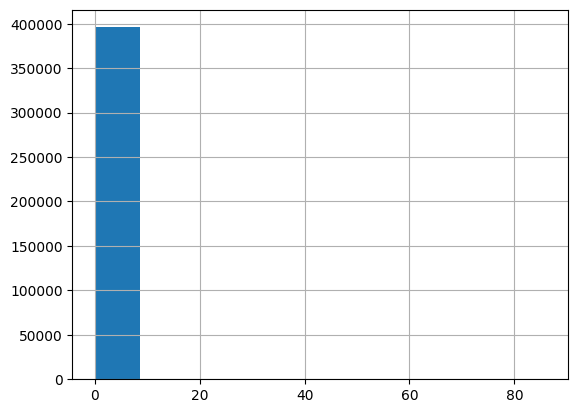

In [23]:
df['pub_rec'].hist()

In [24]:
df['pub_rec'].value_counts().head(5)

,count
pub_rec,
0.0,338272
1.0,49739
2.0,5476
3.0,1521
4.0,527


- Extreamly concentrated. Nearlt all values are between 0-10
- There are a few very large outliars.
- Unimodal and ~83% of data is 0.

In [25]:
df['revol_bal'].describe()

,revol_bal
count,3.960300e+05
mean,1.584454e+04
std,2.059184e+04
min,0.000000e+00
25%,6.025000e+03
50%,1.118100e+04
75%,1.962000e+04
max,1.743266e+06


The `revol_bal` stands for Revolving Balance. This refers to the total outstanding balance that a borrower has across all their revolving credit accounts, such as credit cards and lines of credit. It represents the amount of money a borrower currently owes on their credit lines that they can continuously draw from and repay.

In [26]:
df['revol_util'].describe()

,revol_util
count,395754.000000
mean,53.791749
std,24.452193
min,0.000000
25%,35.800000
50%,54.800000
75%,72.900000
max,892.300000


`revolv_util` how much of your available revolving credit you're actually using, as a percentage.
Revolving credit = credit cards, lines of credit — limits you can borrow against repeatedly. If your cards total a 10,000 limit and you're carrying 3,000 in balance, your revol_util is 30%.

In [27]:
df['total_acc'].describe()

,total_acc
count,396030.000000
mean,25.414744
std,11.886991
min,2.000000
25%,17.000000
50%,24.000000
75%,32.000000
max,151.000000


- "Credit line" here = any credit account the borrower has ever had on file — not just active ones.
- So `total_acc` counts every account in their credit history: credit cards, auto loans, mortgages, student loans, store cards open or closed, all of it.
- Contrast with `open_acc`, which you also have: that's only the accounts currently open. So `total_acc` ≥ `open_acc` always (total includes the closed ones too).

In [28]:
df['mort_acc'].value_counts().head(5)

,count
mort_acc,
0.0,139777
1.0,60416
2.0,49948
3.0,38049
4.0,27887


- This is a niche feature which is most useful for loan applicants with mortage as the puprose of loan. It also plays a small factor in understanding the applicant's overall credit status.

**Open, total and mortage account:**

- `open_acc` (Open Accounts): The number of credit lines that are currently active and open right now (e.g., credit cards you currently use, active auto loans).

- `total_acc` (Total Accounts): The total number of credit lines the borrower has ever had in their credit history. This includes everything in open_acc plus all historically closed accounts (e.g., paid-off student loans, canceled credit cards).

- `mort_acc` (Mortgage Accounts): A specific sub-category counting how many home loans (active or historical) the borrower has.

`total_acc` will always be greater than or equal to `open_acc` because it captures the borrower's entire credit lifetime. (As you noticed in your notebook check, simply adding `open_acc + mort_acc` will not equal total_acc because mort_acc is already mixed into those counts, and `total_acc` includes closed accounts of all types).

In [29]:
df['pub_rec_bankruptcies'].value_counts()

,count
pub_rec_bankruptcies,
0.0,350380
1.0,42790
2.0,1847
3.0,351
4.0,82
5.0,32
6.0,7
7.0,4
8.0,2


- Almost ~90% of people have no public record of bankruptcies.
- Intuitively this is a very important metric.

## Exploratory Data Analysis

1. Target analysis
2. Univariate Analysis for Numerical data

### Target Analysis


`loan_status` is our target variable.

In [30]:
df['loan_status'].value_counts()

,count
loan_status,
Fully Paid,318357
Charged Off,77673


<Axes: xlabel='loan_status'>

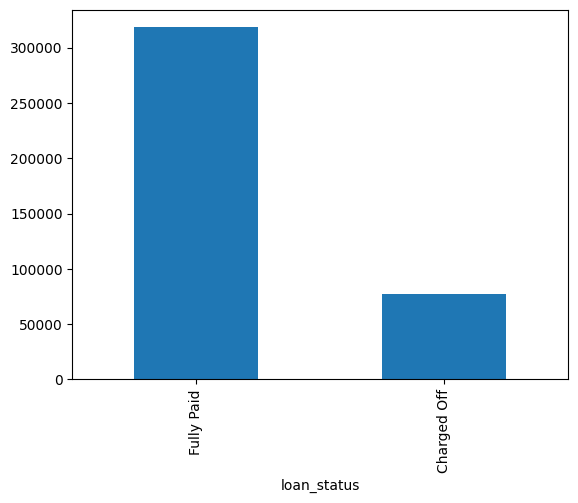

In [31]:
df['loan_status'].value_counts().plot(kind='bar')

- 20% of the applicants have defaulted in our data.

Problem statement tells us to predict the loan defaulter. So, we choose class 1 as "Charged off".


**Target Metrics:**

- Recall = "of all real defaulters, how many did we catch?"
- Precision = "of everyone we flagged as defaulter, how many truly defaulted?"

- Accuracy metric is not useful since there is a 1:4 imabalance in our target classes.

###  Univariate Analysis for Numerical data

In [32]:
df.select_dtypes(exclude='object').columns

Index(['loan_amnt', 'int_rate', 'installment', 'annual_inc', 'dti', 'open_acc',
       'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'mort_acc',
       'pub_rec_bankruptcies'],
      dtype='object')

#### Loan Amount

In [33]:
df['loan_amnt'].describe()

,loan_amnt
count,396030.000000
mean,14113.888089
std,8357.441341
min,500.000000
25%,8000.000000
50%,12000.000000
75%,20000.000000
max,40000.000000


<Axes: >

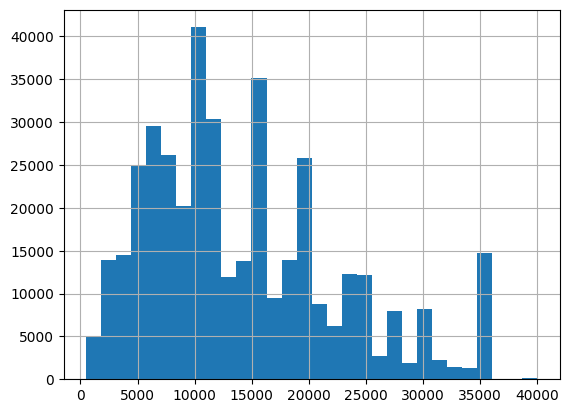

In [34]:
df['loan_amnt'].hist(bins=30)

In [35]:
df.isna().sum()['loan_amnt']

np.int64(0)

- There is no nan or impossible values like 0.
- The loan amount has a mean of 14K and has a wide range of 500-40K

- The globally right-skewed, with local peaks at round amounts (10/15/20k) due to human preference for round figures.
- The 35k spike is the max. A pile-up near the maximum (40K) often means the value is capped.

**Hypothesis:**

Loan amount might have a strong relationship to the target. Probability of default, possibly accelerating at the extremes

#### Interest Rate

In [36]:
df['int_rate'].isna().sum() , (df['int_rate'] == 0).sum()

(np.int64(0), np.int64(0))

In [37]:
df['int_rate'].describe()

,int_rate
count,396030.000000
mean,13.639400
std,4.472157
min,5.320000
25%,10.490000
50%,13.330000
75%,16.490000
max,30.990000


<Axes: >

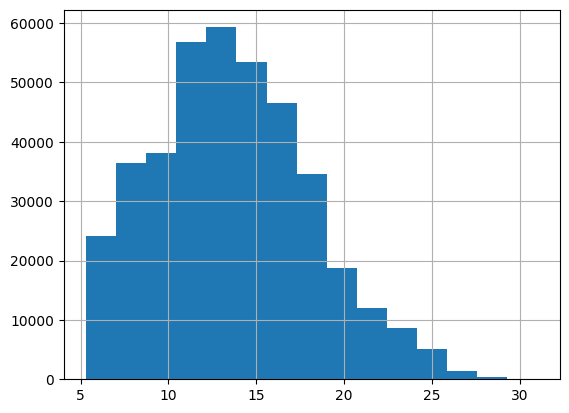

In [38]:
df['int_rate'].hist(bins=15)

- Unimodal, Right skewed with a long tail as the itnerest rate increases.
- Most applicants are priced at 7–17%, meaning the portfolio is mostly lower-to-mid risk
- The interest rates above 25 can be considered as very high risk applicanrs. Since their high interest rate indicates their bad credit health.

**Hypothesis:**

Interest in the range 7-17 monotonic relation to target but interest that are on the extreme might drastically increases the change of default.

#### Debt-to-Income (DTI) ratio

In [39]:
df['dti'].describe()

,dti
count,396030.000000
mean,17.379514
std,18.019092
min,0.000000
25%,11.280000
50%,16.910000
75%,22.980000
max,9999.000000


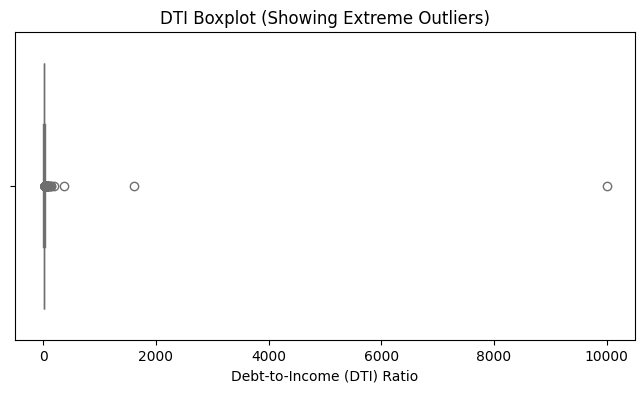

In [40]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['dti'], color='skyblue')
plt.title('DTI Boxplot (Showing Extreme Outliers)')
plt.xlabel('Debt-to-Income (DTI) Ratio')
plt.show()

DTI of 9999% is impossible (it'd mean debt payments 100× income). Systems often dump 9999 or -1 when the true value is missing. So treat it as a missing-value/data-quality issue, not a genuine extreme.

Lets ignore the extreme outliars and focus on the general trend of the dti.

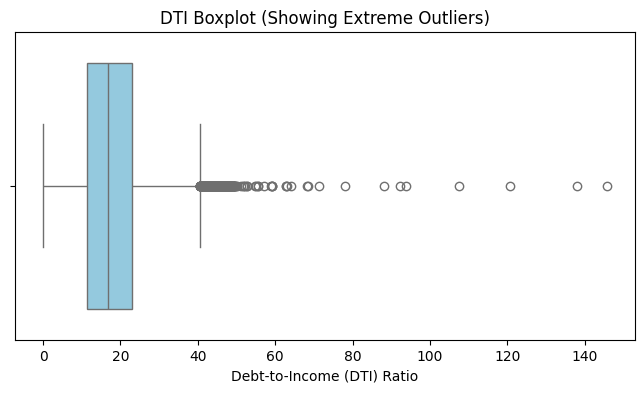

In [41]:
dti = df[df['dti'] < 175]['dti']

plt.figure(figsize=(8, 4))
sns.boxplot(x=dti, color='skyblue')
plt.title('DTI Boxplot (Showing Extreme Outliers)')
plt.xlabel('Debt-to-Income (DTI) Ratio')
plt.show()

<Axes: >

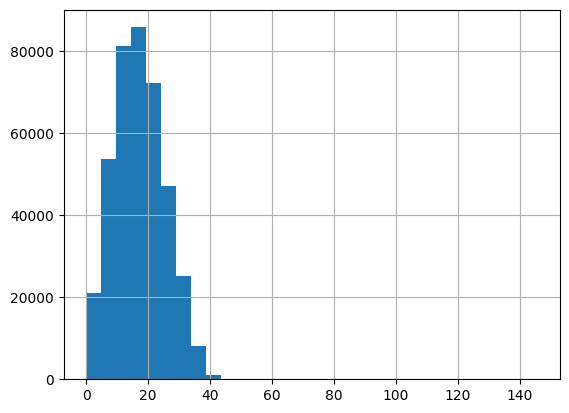

In [42]:
dti.hist(bins=30)

- The data is strongly concentrated between 0 and 35 with a peak at 15-20
- It's unimodal and roughly symmetric in the bulk, but there's a clear long right tail.
- The mean is 17 and 75% is ~23 but the max is 9999 suggesting big outliars.
- A dti above 100 means the applican't can never payoff the loan uisng the income which itself is a huge indicator of loan default.

Let's analyse the extreme `dti` scores.

In [43]:
(df['dti'] == 0).sum()

np.int64(313)

In [44]:
(df['dti'] > 50).sum()

np.int64(35)

Check for impossible data:

In [45]:
(df['dti'] > 100).sum()

np.int64(8)

In [46]:
df[df['dti'] > 200]['dti']

,dti
285674,9999.00
338571,380.53
350865,1622.00


- DTI measures debt excluding mortgage and the requested LoanTap loan. So `dti = 0` just means: before this loan, they had no other monthly debt obligations.

- A DTI of above 1000 is impossible data. Values in the range are placeholder codes or unit errors (someone fed a raw balance instead of a ratio). These are data corruption.

- DTI benchmark:

  - Low DTI ($\le 36\%$): Good financial health. The borrower has plenty of income left over after paying bills.
  
  - High DTI ($\ge 50\%$): High risk. Most of the borrower's income goes toward paying off existing debt, making them highly susceptible to defaulting if they hit financial trouble.

**Hypothesis:**

High dti is directly related to high default chances. A dti of 50 or above exponentially increases the chances of default.

#### Annual income

Note:  Pandas switches to scientific notation when numbers span a wide range, because printing 8000000.00 next to 4500.00 in a table is ugly and hard to align. It's purely display; the underlying values are exact.

<Axes: >

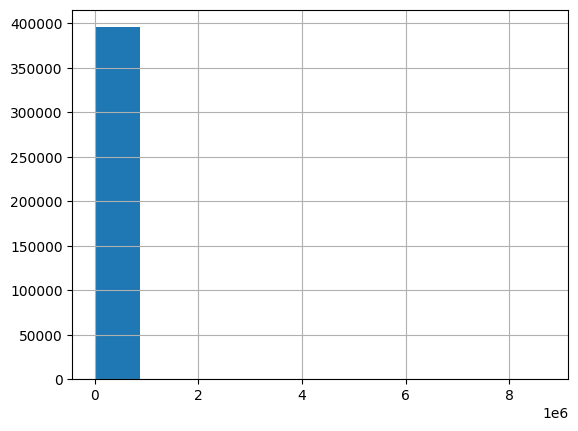

In [47]:
df['annual_inc'].hist()

In [48]:
df['annual_inc'].describe()

,annual_inc
count,3.960300e+05
mean,7.420318e+04
std,6.163762e+04
min,0.000000e+00
25%,4.500000e+04
50%,6.400000e+04
75%,9.000000e+04
max,8.706582e+06


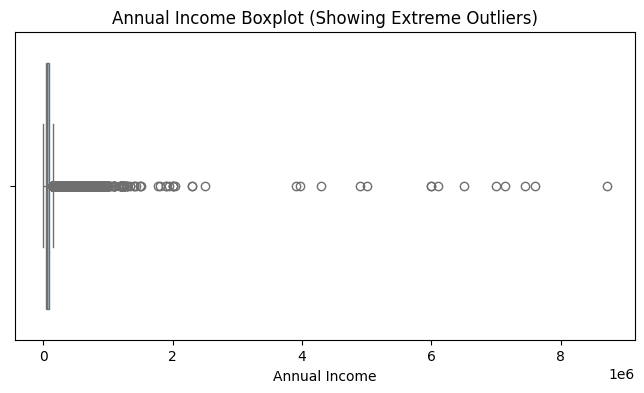

In [49]:
annual_inc = df['annual_inc']

plt.figure(figsize=(8, 4))
sns.boxplot(x=annual_inc, color='skyblue')
plt.title('Annual Income Boxplot (Showing Extreme Outliers)')
plt.xlabel('Annual Income')
plt.show()

Let's ignore the extreme outliars to understand the trend.

In [50]:
df['annual_inc'][df['annual_inc'] >= 1000000].shape

(75,)

In [51]:
df['annual_inc'][df['annual_inc'] >= 500000].shape

(491,)

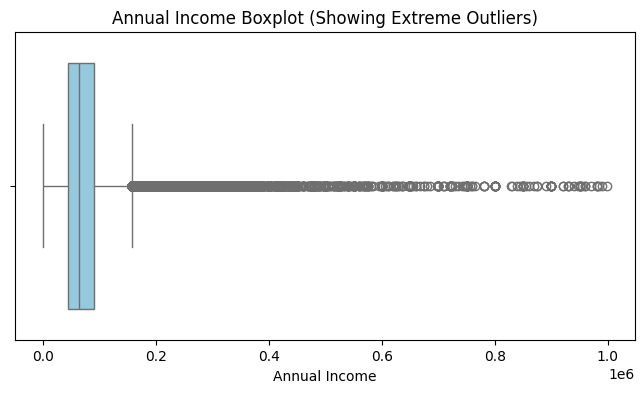

In [52]:
annual_inc = df['annual_inc'][df['annual_inc'] < 1000000]

plt.figure(figsize=(8, 4))
sns.boxplot(x=annual_inc, color='skyblue')
plt.title('Annual Income Boxplot (Showing Extreme Outliers)')
plt.xlabel('Annual Income')
plt.show()


- The min annual income value is 0 and the max is ~8M
- The 75% value is 90,000 which compared to max ~8M suggests that the annual income data is right skewed and has many outliars.

In [53]:
df['annual_inc'][df['annual_inc'] == 0].shape

(1,)

In [54]:
df[['annual_inc','dti','loan_status','loan_amnt']][df['annual_inc'] == 0]

,annual_inc,dti,loan_status,loan_amnt
285674,0.0,9999.0,Charged Off,3700.0


`annual_inc = 0` is suspect, unlike `dti = 0`. A salaried-lending platform shouldn't be funding someone with literally zero income it contradicts their whole model. So it's likely either a data error or a borrower whose income wasn't reported/verified.

**Hypothesis:**

I expect higher annual income to associate with lower default rates, because higher earners have more cushion to cover payments. But the data is heavily skewed a 8M earner and a 200K earner both have repaying ability so the relationship maybe weak and not linear.

#### Installment

<Axes: >

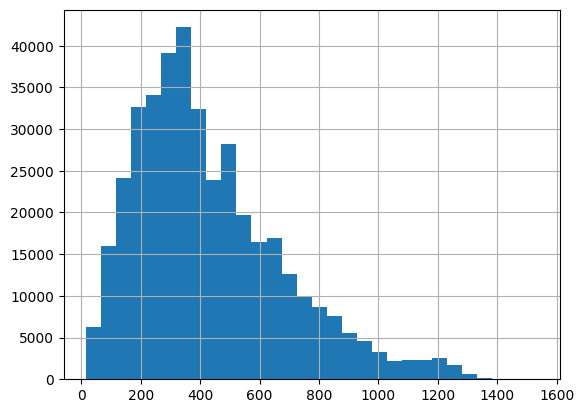

In [55]:
df['installment'].hist(bins=30)

<Axes: >

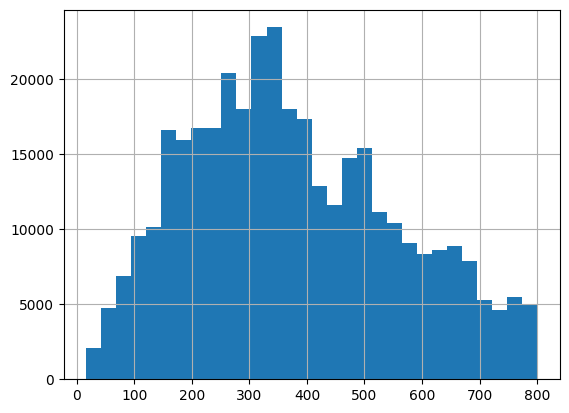

In [56]:
df[df['installment']<800]['installment'].hist(bins=30)

- Unimodal distribution. The data in concentrated around 150-400 with a peak around 370.
- Right skewed with a long tail as the installemnt ammount increases.

**Hypothesis:**
It's strong correlation with loan amount is expected. Since it's derived from the loan amount.


#### Revolving Balance

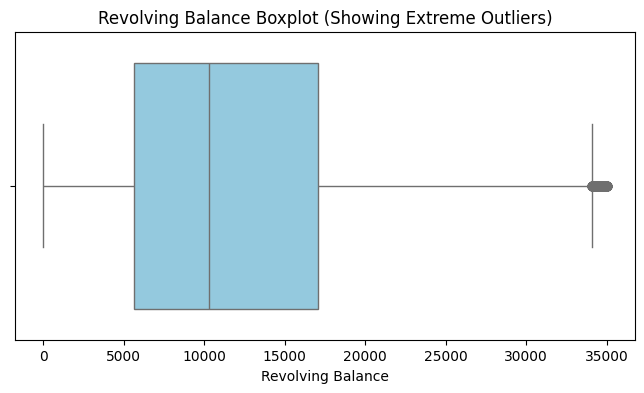

In [57]:
revol_bal = df[df['revol_bal'] < 35000]['revol_bal']

plt.figure(figsize=(8, 4))
sns.boxplot(x=revol_bal, color='skyblue')
plt.title('Revolving Balance Boxplot (Showing Extreme Outliers)')
plt.xlabel('Revolving Balance')
plt.show()

In [58]:
df['revol_bal'].describe()

,revol_bal
count,3.960300e+05
mean,1.584454e+04
std,2.059184e+04
min,0.000000e+00
25%,6.025000e+03
50%,1.118100e+04
75%,1.962000e+04
max,1.743266e+06


<Axes: >

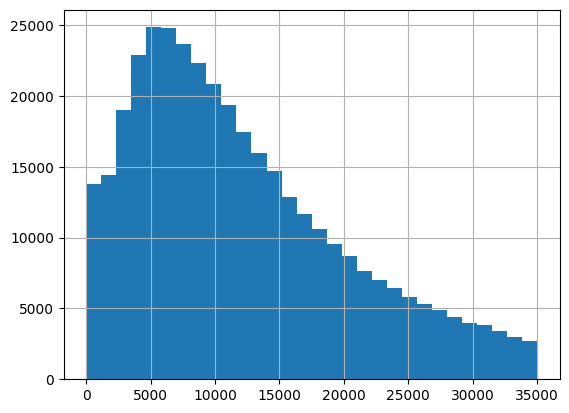

In [59]:
revol_bal.hist(bins=30)

In [60]:
(df['revol_bal'] < 35000 ).sum() / df.shape[0]

np.float64(0.923144711259248)

-  Revol balance = 0 is fine here (many people carry no revolving debt).
- ~5% of applicants have 0 revol balance and ~92% applicants have less than 35K revol blance.
- Extreme right skew, classic revolving-balance shape. Mean (15,844) > median, long tail of a few high-balance borrowers.

**Hypothesis:**

A revolvoing is balance is basically outstanding debt. So, inituitively the higher the outstanding debt the higher the change of default. But it also depends on signifaicantly on factors like income, credit limit and debt purpose. It might be a weak feature on its won but a strong feature when conbined with other related metrics.

#### Revolving Util

<Axes: >

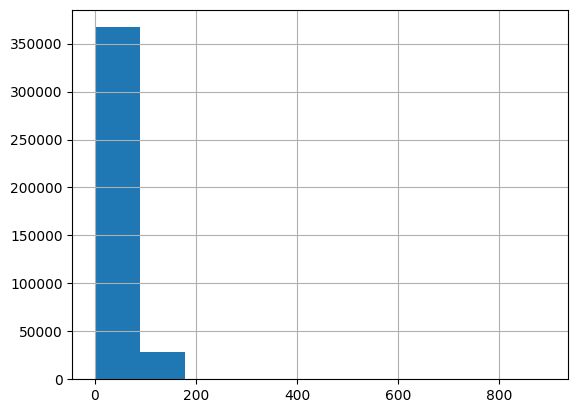

In [61]:
df['revol_util'].hist()

<Axes: >

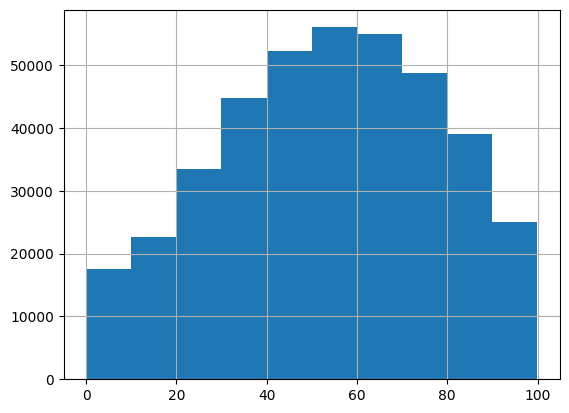

In [62]:
revol_util = df[df['revol_util'] < 100]['revol_util']
revol_util.hist()

- Extreme right skew with a long tail. If we focus on the realistic range 0-100 there is no sharp peak.
- min = 0 is fine here (many people carry no revolving debt).
- Values above 100 are caused by fees compounding, interest, or the issuer allowing overage.
-  Since the top 2 loan purpose of loan applicant are for "credit card" and "debt_consolidation". This is a important feature to decide the credit health of the applicant.

**Hypothesis:**

Strong standalone predictor. Utilization directly measures credit stress, someone near 100% has no headroom and is financially stretched, signaling high default risk. Unlike revol_bal, it's already normalized by credit limit, so it doesn't need other features to be meaningful.

#### Open Accounts

In [63]:
df['open_acc'].describe()

,open_acc
count,396030.000000
mean,11.311153
std,5.137649
min,0.000000
25%,8.000000
50%,10.000000
75%,14.000000
max,90.000000


<Axes: >

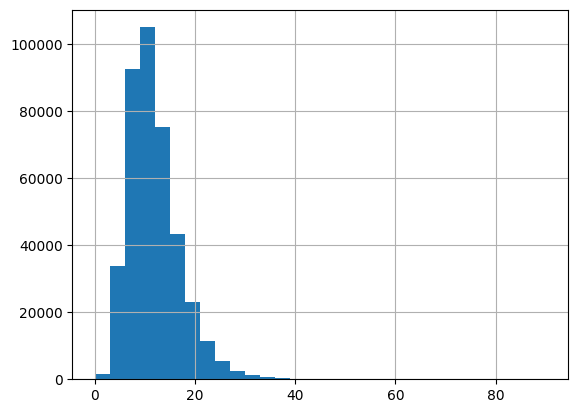

In [64]:
df['open_acc'].hist(bins=30)

In [65]:
df[df['open_acc'] >= 50][['loan_amnt','annual_inc','open_acc','dti','revol_util']].agg('mean')

,0
loan_amnt,18179.032258
annual_inc,99163.870968
open_acc,55.451613
dti,22.215161
revol_util,38.458065


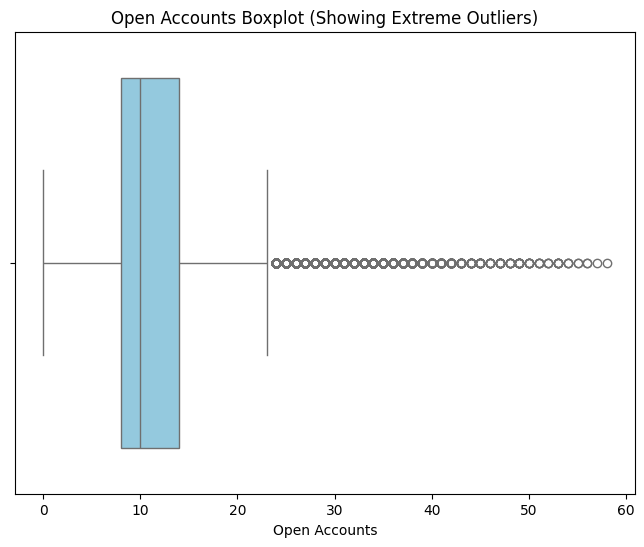

In [66]:
open_acc = df[df['open_acc'] < 60]['open_acc']

plt.figure(figsize=(8,6))
sns.boxplot(x=open_acc, color='skyblue')
plt.title('Open Accounts Boxplot (Showing Extreme Outliers)')
plt.xlabel('Open Accounts')
plt.show()

- Right skewed with a long tail.
- The >50 value are mostly associated with HNIs mean income 100K. They are few but extreme and less frequent outliars.

**Hypothesis:**

The number of open account by itself is not a strong predictor. But we can find strong realitionship between credit util and income.

#### Mortgage Account

<Axes: >

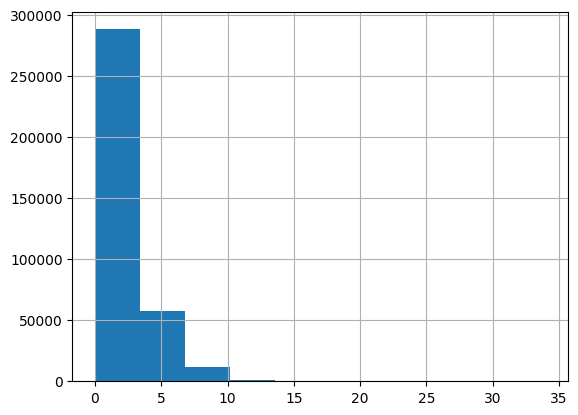

In [67]:
df['mort_acc'].hist()

In [68]:
df['mort_acc'].value_counts().iloc[:5]

,count
mort_acc,
0.0,139777
1.0,60416
2.0,49948
3.0,38049
4.0,27887


- Strong Positive Skew with a long tail.
- Mode is 0 with 35% of applicant and has a wide range of 0 to 35
- This is a niche metric and important only for users with mortgage loan or high credit assemenet.

**Hypothesis:**

This is not a strong predictor of target class. It might be a important metric for mortgage loans.

#### Total Account

In [69]:
(df['total_acc'] < df['open_acc']).sum()

np.int64(0)

In [70]:
df['total_acc'].mode()

,total_acc
0,21.0


<Axes: >

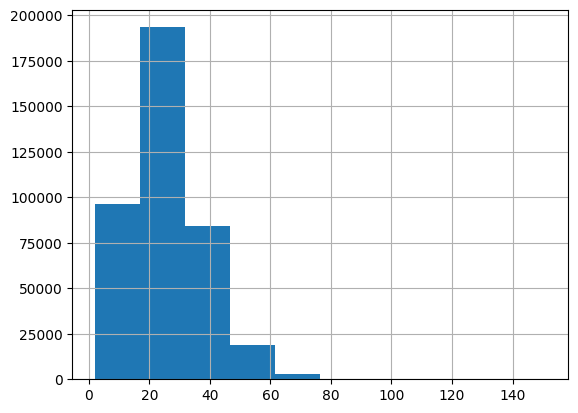

In [71]:
df['total_acc'].hist()

- Right Skewed Unimodal with a long tail.
- There is a clear huge peak around 15-30
- The mode is around 21 and there accounts that have values as high as 151
- There is no impossible data (open acc > total acc)

**Hypothesis:**
Its not a strong predictior of the target class. Features like 'revol_util' and 'open_acc' are rpobably strongly related to this feature.

#### Public Record

In [72]:
df['pub_rec'].value_counts().iloc[:5]

,count
pub_rec,
0.0,338272
1.0,49739
2.0,5476
3.0,1521
4.0,527


<Axes: >

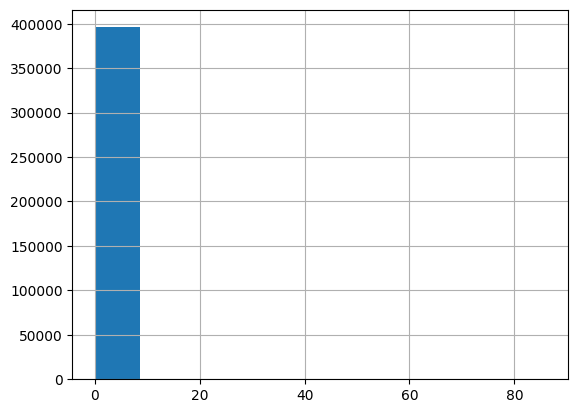

In [73]:
df['pub_rec'].hist()

- 85% of applicants have no public record.
- 99.99 % of data lies between 0 and 10 but the max values extend till 86.
- Its heavily right skewed.

**Hypothesis:**

Its probably a important predictor since majority has no records, the applicants with records are at a higher likelyhood of getting rejected for loan.

#### Bankruptcy Record

In [74]:
(df['pub_rec_bankruptcies'] == 0).sum() / df.shape[0]

np.float64(0.8847309547256521)

<Axes: >

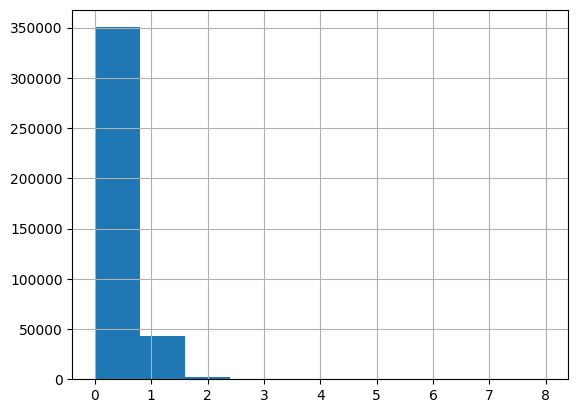

In [75]:
df['pub_rec_bankruptcies'].hist()

- They data is heavily right skewed with a long tail.
- 88% of applicant have no record and that makes the peak at 0

**Hypothesis:**  
This is a very important metric since it's directly related to default. Applicants with even 1 record will have a significant disadvantage and high likelyhood of getting rejected.

### Univariate Analysis for Categorical Data

In [76]:
df.select_dtypes(include='object').columns

Index(['term', 'grade', 'sub_grade', 'emp_title', 'emp_length',
       'home_ownership', 'verification_status', 'issue_d', 'loan_status',
       'purpose', 'title', 'earliest_cr_line', 'initial_list_status',
       'application_type', 'address'],
      dtype='object')

#### Term

In [77]:
df['term'].isna().sum() , df['term'].nunique()

(np.int64(0), 2)

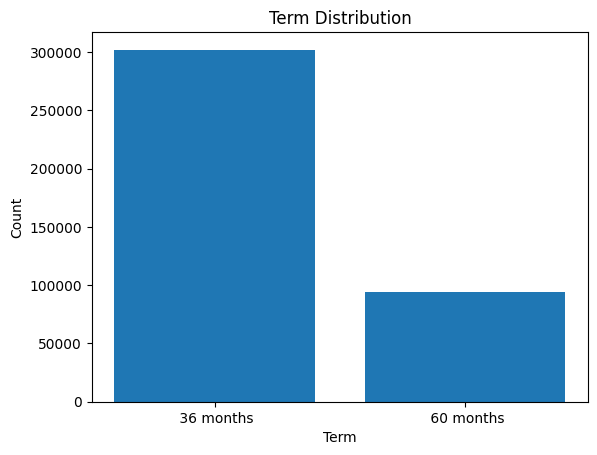

In [78]:
plt.bar(x=df['term'].value_counts().index, height=df['term'].value_counts().values)
plt.xlabel("Term")
plt.ylabel("Count")
plt.title("Term Distribution")
plt.show()

In [79]:
df['term'].value_counts(normalize=True) * 100

,proportion
term,
36 months,76.258112
60 months,23.741888


- There is a 1:3 ratio which indicates that 3 out of 4 perple perfer 36 month period.
- No default, nan or impossible value.
**Hypothesis:**

60-month loans are riskier lending. I am expecting a higher default rate in the 60mo group.

#### Grade & Sub Grades

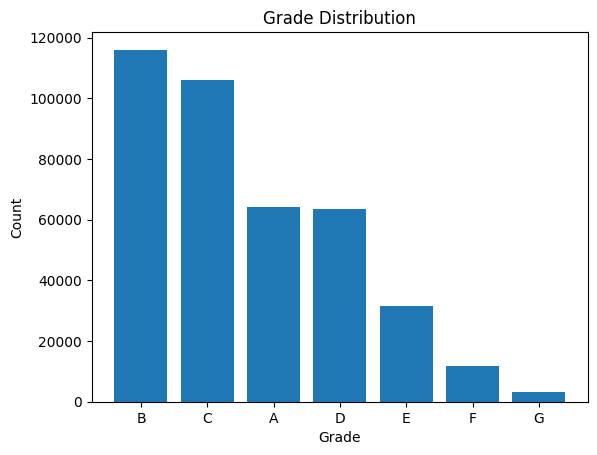

In [80]:
plt.bar(df['grade'].value_counts().index , df['grade'].value_counts().values)
plt.xlabel("Grade")
plt.ylabel("Count")
plt.title("Grade Distribution")
plt.show()

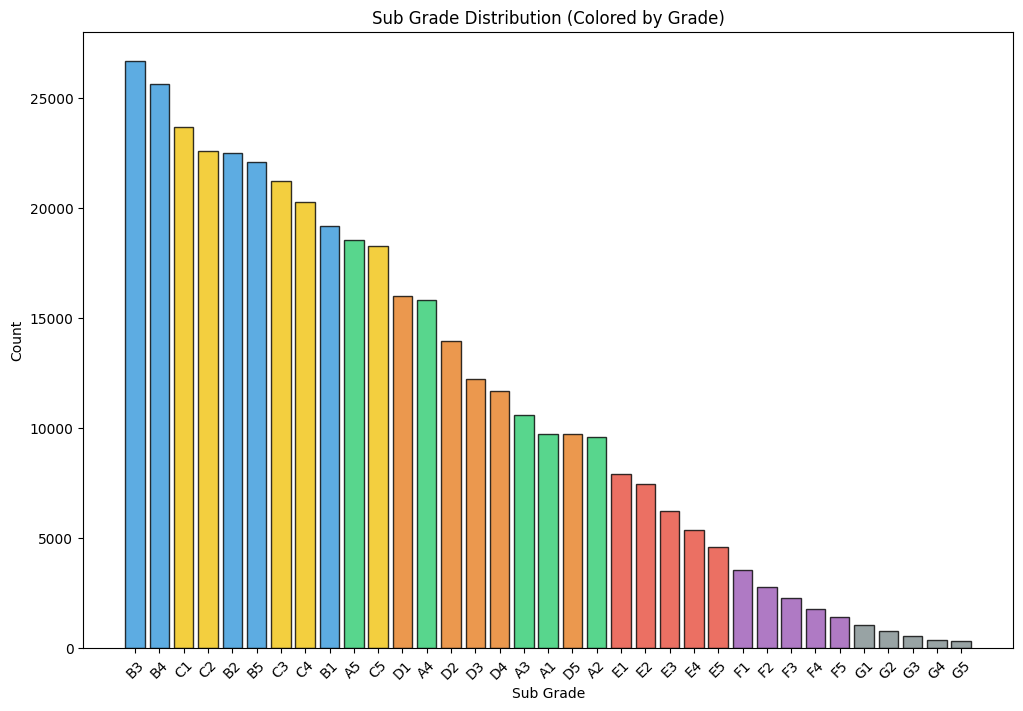

In [81]:
sub_grade_counts = df['sub_grade'].value_counts()

grade_colors = {
    'A': '#2ecc71',  # Green
    'B': '#3498db',  # Blue
    'C': '#f1c40f',  # Yellow
    'D': '#e67e22',  # Orange
    'E': '#e74c3c',  # Red
    'F': '#9b59b6',  # Purple
    'G': '#7f8c8d'   # Grey
}

bar_colors = [grade_colors[sg[0]] for sg in sub_grade_counts.index]

plt.figure(figsize=(12, 8))
plt.bar(
    sub_grade_counts.index,
    sub_grade_counts.values,
    color=bar_colors,
    edgecolor='black',
    alpha=0.8
)

plt.xlabel("Sub Grade")
plt.ylabel("Count")
plt.title("Sub Grade Distribution (Colored by Grade)")
plt.xticks(rotation=45)
plt.show()

- The order of the dataset's grade is `B > C > A > D > E > F > G`
- The loan volume concentrates in grades B,C ; counts fall almost ~3000 after that for A, D; and after that fall steadily for E, F, G
- Confirms LoanTap mostly serves mid-risk borrowers and limits exposure to the lowest grades.


#### Home Ownership

Text(0.5, 1.0, 'Home Ownership Distribution')

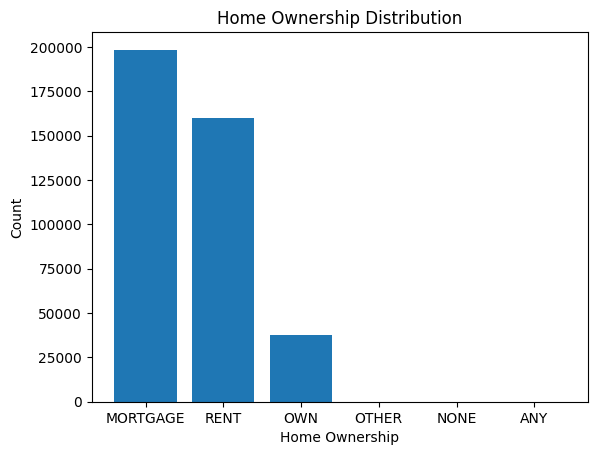

In [82]:
index = df['home_ownership'].value_counts().index
values = df['home_ownership'].value_counts().values

plt.bar(index,values)
plt.xlabel("Home Ownership")
plt.ylabel("Count")
plt.title("Home Ownership Distribution")

In [83]:
low_ownership_categories = ['OTHER','NONE',"ANY"]
df['home_ownership'].isin(low_ownership_categories).sum()

np.int64(146)

In [84]:
home = df['home_ownership'].value_counts()[:3] / df.shape[0] * 100

[Home Ownsership categories defination](https://colab.research.google.com/drive/12yB5KRTwZ_ZxdsaXoKzprhmJGIfGxez-#scrollTo=WaQg1A-AKkq5)


- Since the 146 is not even 0.1% of our data we can merge them into a rare category.

- ~89% of our loan applicants are on mortgage or rent and ~9% percentage own their own home.

**Hypothesis:**
Since the majority of applicants are 'morgage' or 'rent' category; New applicants will have a higher chance of getting the loan for mortgage and rent. In bivariance analysis we can verify this intuition.

#### Employeement

In [85]:
df['emp_title'].nunique()

173105

Text(0.5, 1.0, 'Employment Length Distribution')

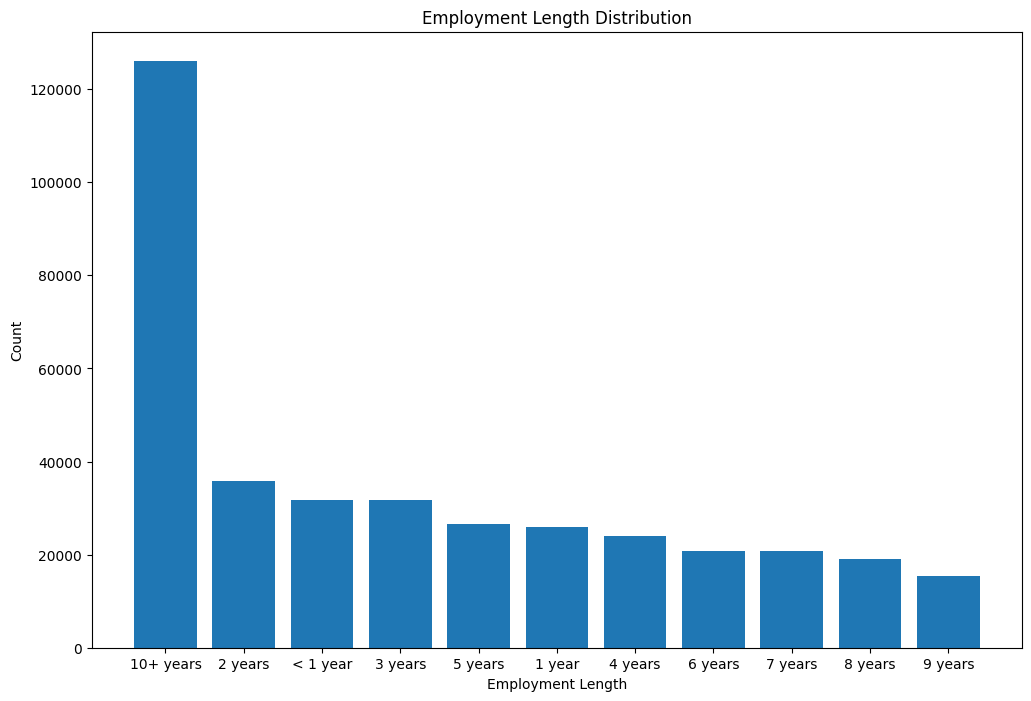

In [86]:

index = df['emp_length'].value_counts().index
values = df['emp_length'].value_counts().values

plt.figure(figsize=(12,8))
plt.bar(index,values)
plt.xlabel("Employment Length")
plt.ylabel("Count")
plt.title("Employment Length Distribution")

- 10+ years is the largest group; counts otherwise fairly even across tenures.
- Since the years are mostly in random order except for 10+yr. We can create a new feature +10 yrs exp as a yes/no category.
- There are 173K unique employee titles. Which is extremely high cardinality. We can ignore it or for advanced feature engineering create buckets of common professions.

#### Purpose

Text(0.5, 1.0, 'Purpose Distribution')

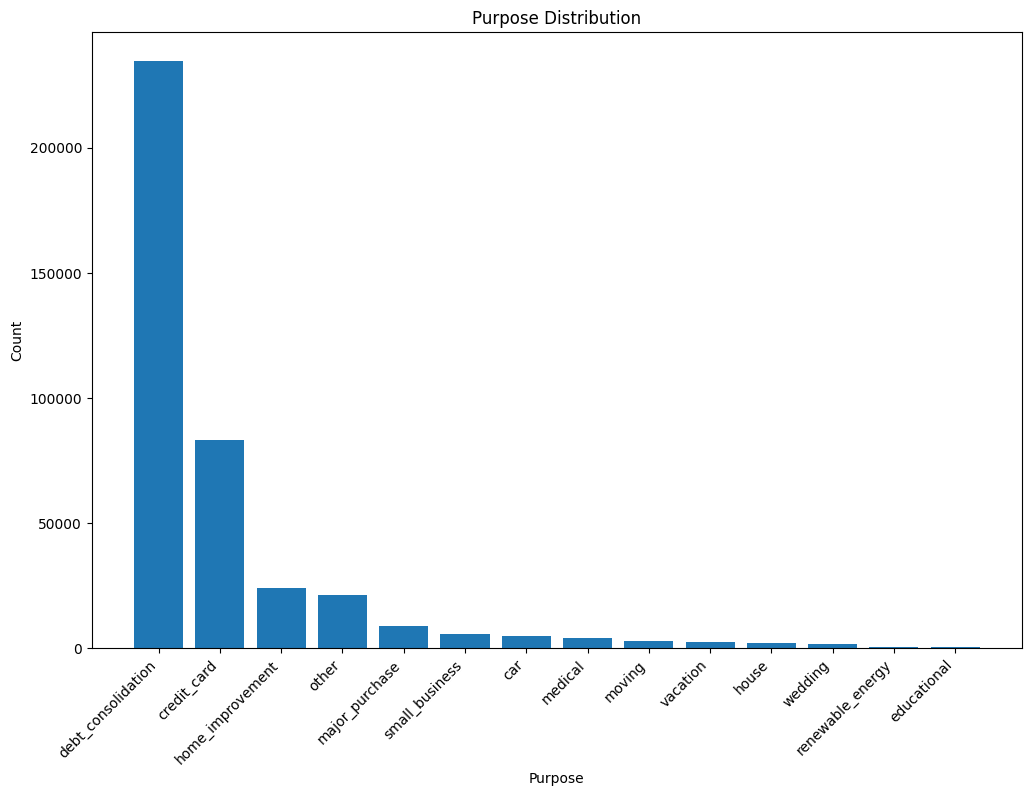

In [87]:
items = df['purpose'].value_counts().index
values = df['purpose'].value_counts().values

plt.figure(figsize=(12,8))
plt.bar(items,values)
plt.xlabel("Purpose")
plt.xticks(rotation=45, ha='right')
plt.ylabel("Count")
plt.title("Purpose Distribution")

In [88]:
values[3]/values.sum()

np.float64(0.05349342221548872)

- ~59% of values are `debt_consolidation`and ~21% are of `credit_card` ~6% are of `home_improvement` and ~5% are `others`
- Since the first 4 caetegories make up a ~91% of the dataset's purpose. We can combine the rest into a minority category.
- Majority of applicants are applying for improving their exisitng credit situation. This insight helps us to focus more on the credit ratios and credit utlilzation metrics.

**Hypothesis:**

Purpose of the loan plays a huge part in deciding the importance of the metrics. Its a important predictor of the target class.

#### Verification Status


Text(0.5, 1.0, 'Verification Status Distribution')

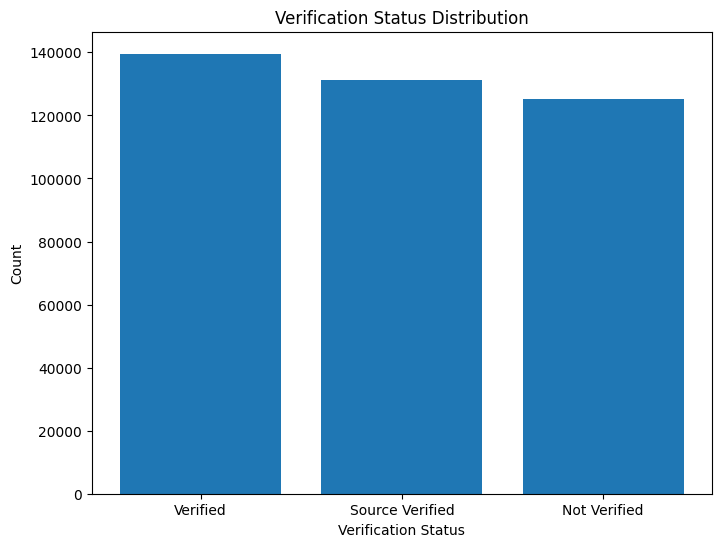

In [89]:

items = df['verification_status'].value_counts().index
values = df['verification_status'].value_counts().values

plt.figure(figsize=(8,6))
plt.bar(items,values)
plt.xlabel("Verification Status")
plt.ylabel("Count")
plt.title("Verification Status Distribution")

- The data is mostly balanced between the three categories.

**Hypothesis:**

Expecting not-verified to relate to default, but direction unclear; verify in bivariate.

<span id="verification-status-cell"></span>

#### Title of the loan

In [90]:
df['title'].nunique()

48816

- Its extreme cardinality and `purpose` give us the same data we woll get if we extract this by grouping common keywords. It might be useful in some specific cases or during advanced feature engineering.

#### Initital List status

Text(0.5, 1.0, 'Initial List Status Distribution')

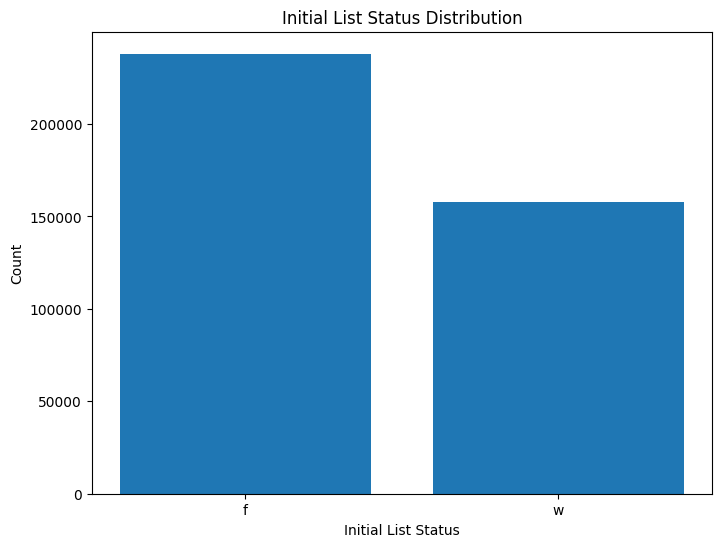

In [91]:
index = df['initial_list_status'].value_counts().index
values = df['initial_list_status'].value_counts().values

plt.figure(figsize=(8,6))
plt.bar(index,values)
plt.xlabel("Initial List Status")
plt.ylabel("Count")
plt.title("Initial List Status Distribution")

- The majority of the loans on the platforms are funded by investors partially. This means we can get more insights by analysing this category against featues like loan amount, interest rate, purpose etc.

#### Application Type

In [92]:
df['application_type'].value_counts()

,count
application_type,
INDIVIDUAL,395319
JOINT,425
DIRECT_PAY,286


In [93]:
(df['application_type'].value_counts().values / df.shape[0] ).round(3) * 100

array([99.8,  0.1,  0.1])

- A negligible ~0.02% contribution of the `DIRECT_PAY` and the `JOINT`. During feature engineering we can consider dropping this feature.
- The `INDIVIDUAL` type dominates the data with 99.9%

#### Other Columns:
- [`loan_status` is analysed in the target analysis](https://colab.research.google.com/drive/12yB5KRTwZ_ZxdsaXoKzprhmJGIfGxez-#scrollTo=PVSIZjeDKmVA)

- [`issue_d` is more relevant suring the bivariance analysis.](https://colab.research.google.com/drive/12yB5KRTwZ_ZxdsaXoKzprhmJGIfGxez-#scrollTo=XO0KKhN3J5U8&line=1&uniqifier=1 )
- [`address` can be used to generate more features like zip code and state type data. Its used in the feature engineering section.](https://colab.research.google.com/drive/12yB5KRTwZ_ZxdsaXoKzprhmJGIfGxez-#scrollTo=9DN6JoCcN3r8&line=1&uniqifier=1)
- [`earliest_cr_line` can also be useful during feature analysis. Its out of scope for univariate analysis.](https://colab.research.google.com/drive/12yB5KRTwZ_ZxdsaXoKzprhmJGIfGxez-#scrollTo=pOAN3xMZMaDw&line=1&uniqifier=1)

## Bivariate Analysis

In [94]:
df['loan_status'].value_counts(normalize=True) * 100

,proportion
loan_status,
Fully Paid,80.387092
Charged Off,19.612908


##### Note:

 Since the loan status data in not balanced to compare the trends we need to

**`stat='probability'`** — changes each bar from a *count* to a *fraction*:

```
bar height = (rows in this bin) / (total rows in this group)
```

**`common_norm=False`** — sets what "total rows in this group" means: each class is its own total, normalized separately.

So for the Charged Off class, a bar's height =

```
(Charged Off loans in that bin) / (all Charged Off loans)
```

and same independently for Fully Paid. Each class's bars sum to 1 on their own → both shapes shown at full height → directly comparable.

(With `common_norm=True`, the denominator would be *all loans across both classes*, so Charged Off would only reach ~20% height.)

#### Loan Status Vs Loan Amount

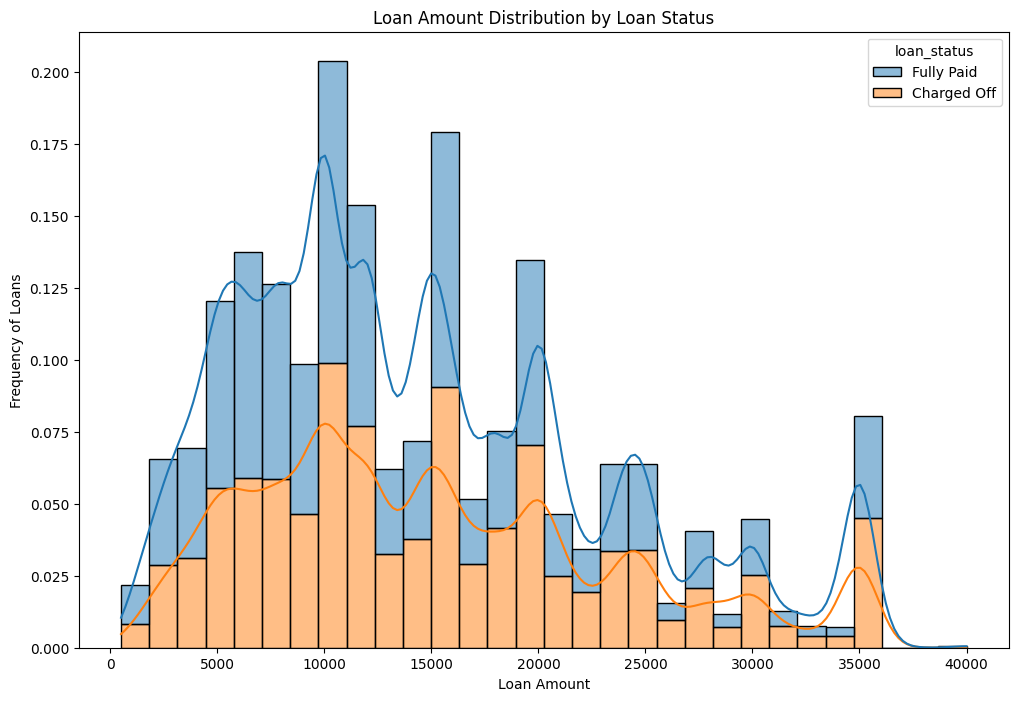

In [95]:
X = df['loan_amnt']

plt.figure(figsize=(12,8))
sns.histplot(data=df, x='loan_amnt',hue='loan_status',bins=30,kde=True,element='bars',stat='probability',common_norm=False,multiple='stack')
plt.title("Loan Amount Distribution by Loan Status")
plt.xlabel("Loan Amount")
plt.ylabel("Frequency of Loans")
plt.show()


- `loan_amnt` distribution nearly identical across `loan_status`.
- Which means **`loan_amnt` is not a good seperator of the target class**.

#### Loan Status Vs Grades

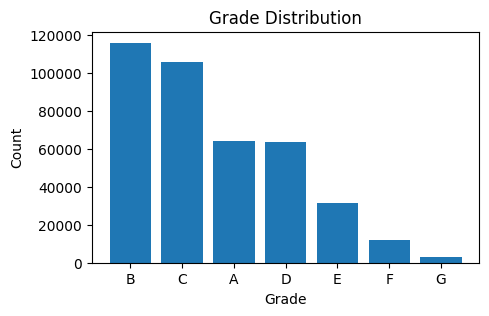

In [96]:
plt.figure(figsize=(5,3))
plt.bar(df['grade'].value_counts().index ,df['grade'].value_counts().values)
plt.xlabel("Grade")
plt.ylabel("Count")
plt.title("Grade Distribution")
plt.show()

In [97]:
df['default'] = df['loan_status'].apply(lambda x: 1 if x == 'Charged Off' else 0)

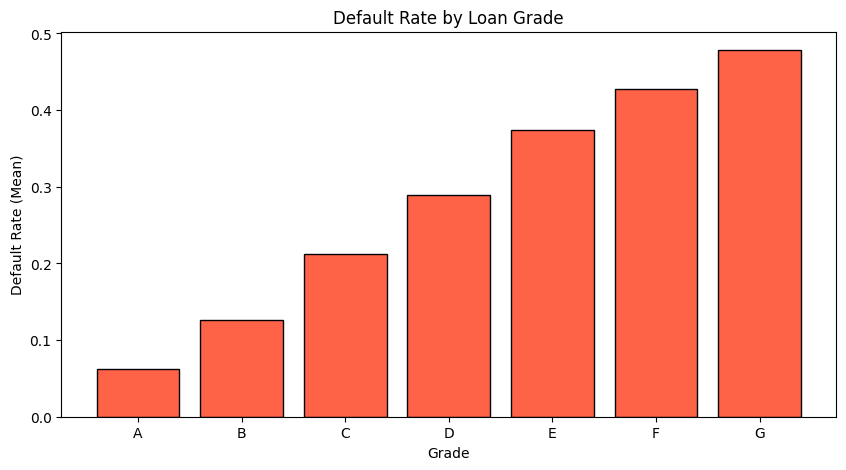

In [98]:
grade_defaults = df.groupby('grade')['default'].mean()

plt.figure(figsize=(10, 5))
plt.bar(x=grade_defaults.index, height=grade_defaults.values, color='tomato', edgecolor='black')

plt.xlabel("Grade")
plt.ylabel("Default Rate (Mean)")
plt.title("Default Rate by Loan Grade")
plt.show()

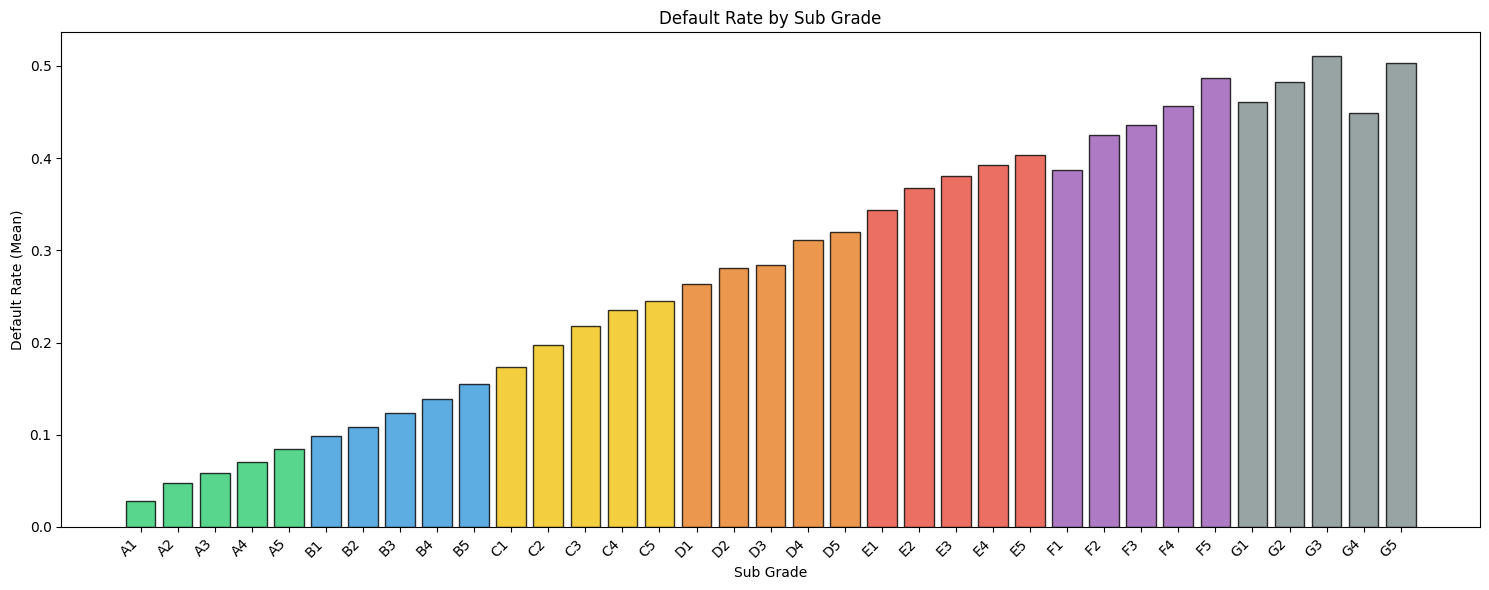

In [99]:
sub_grade_defaults = df.groupby('sub_grade')['default'].mean().sort_index()

grade_colors = {
    'A': '#2ecc71',  # Green
    'B': '#3498db',  # Blue
    'C': '#f1c40f',  # Yellow
    'D': '#e67e22',  # Orange
    'E': '#e74c3c',  # Red
    'F': '#9b59b6',  # Purple
    'G': '#7f8c8d'   # Grey
}

colors = [grade_colors[sg[0]] for sg in sub_grade_defaults.index]

plt.figure(figsize=(15, 6))
plt.bar(
    x=sub_grade_defaults.index,
    height=sub_grade_defaults.values,
    color=colors,
    edgecolor='black',
    alpha=0.8
)


plt.xticks(rotation=45, ha='right')
plt.xlabel("Sub Grade")
plt.ylabel("Default Rate (Mean)")
plt.title("Default Rate by Sub Grade")
plt.tight_layout()
plt.show()

-  A ~6% default → G ~48%. An 8× spread across grades. The sub_grade plot shows this even more smoothly.
- **Grade is one of your best predictors. It has a strong monotonic relationship with the loan status.**
- In the sub grade the G grade is noisy. G4 < G1 because the sample size of G grade is small.

#### Loan Status Vs Employment Length

In [116]:
df[['emp_length','loan_status']].value_counts().iloc[:5]

,,count
emp_length,loan_status,
10+ years,Fully Paid,102826
2 years,Fully Paid,28903
3 years,Fully Paid,25483
< 1 year,Fully Paid,25162
10+ years,Charged Off,23215


Text(0.5, 0, 'Employment Length')

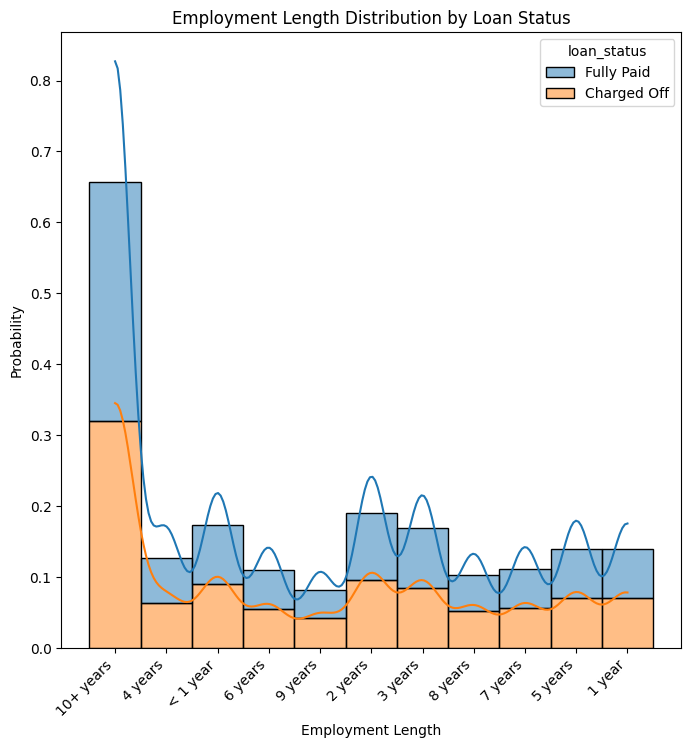

In [120]:
plt.figure(figsize=(8,8))
sns.histplot(data=df, x='emp_length',hue='loan_status',bins=30,kde=True,element='bars',stat='probability',common_norm=False,multiple='stack')
plt.title("Employment Length Distribution by Loan Status")
plt.xticks(rotation=45, ha='right')
plt.xlabel("Employment Length")

- Since the y-axis is normalized we can see the trends of the loan status across employment years and it is almost proportionally divided across the years.
- Which means `emp_length` is not a good seperator of the target class.

#### Loan Status Vs Term

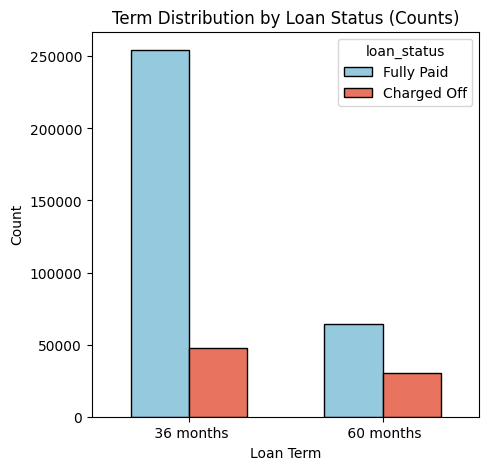

In [138]:
plt.figure(figsize=(5,5))

sns.countplot(
    data=df,
    x='term',
    hue='loan_status',
    palette=['skyblue', 'tomato'],
    edgecolor='black',
    width=0.6
)

plt.title("Term Distribution by Loan Status (Counts)")
plt.xlabel("Loan Term")
plt.ylabel("Count")
plt.show()

In [140]:
df[['term','loan_status']].value_counts()

,,count
term,loan_status,
36 months,Fully Paid,254365
60 months,Fully Paid,63992
36 months,Charged Off,47640
60 months,Charged Off,30033


In [141]:
254365 / 302005 , 63992 / 302005

(0.8422542673134551, 0.21189053161371502)

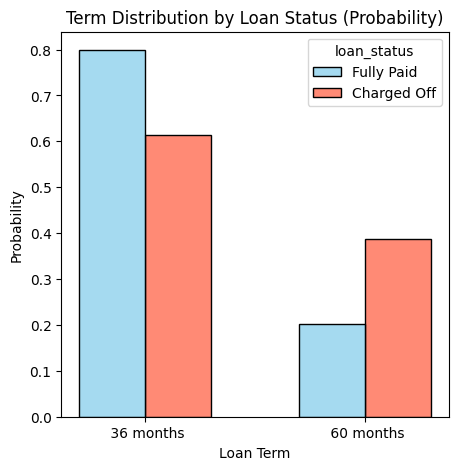

In [145]:
plt.figure(figsize=(5,5))

sns.histplot(
    data=df,
    x='term',
    hue='loan_status',
    palette=['skyblue', 'tomato'],
    stat='probability',      # This changes the y-axis to 0.0 - 1.0 probability
    multiple='dodge',
    shrink=0.6,
    common_norm=False
)

plt.title("Term Distribution by Loan Status (Probability)")
plt.xlabel("Loan Term")
plt.ylabel("Probability")
plt.show()


- Among Fully Paid people: 84% had 36mo, 16% had 60mo.
- Among Charged Off people: 68% had 36mo, 32% had 60mo.
- The applicant's with 60m term are 2x more likely to default.
- So, We can consider `term` as a perdictor of the target class.

#### Loan Status Vs Home Ownership

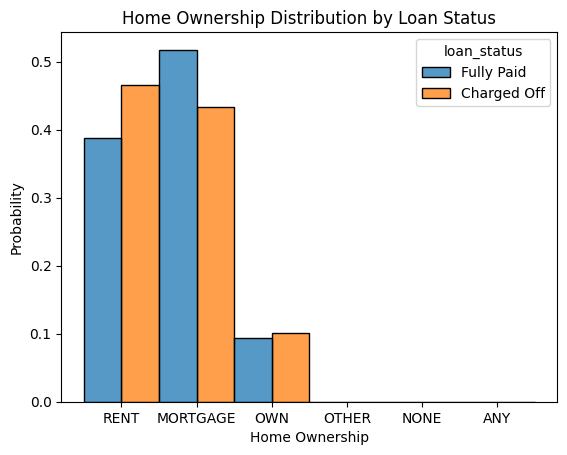

In [154]:
sns.histplot(data=df,x='home_ownership',hue='loan_status',stat='probability',multiple='dodge',common_norm=False)
plt.title("Home Ownership Distribution by Loan Status")
plt.xlabel("Home Ownership")
plt.ylabel("Probability")
plt.show()

- y-axis is normalized so can see the trends of the loan status across applicant's home ownership and it is not proportionally divided.
- Rent applicants defaults slightly more than mortgage which validates our hypothesis of asset ownership increases financial stability but its a weak signal because the difference is ~0.1%
- Which means `home_ownership` is not a good seperator of the target class.

#### Loan Status Vs Verification Status

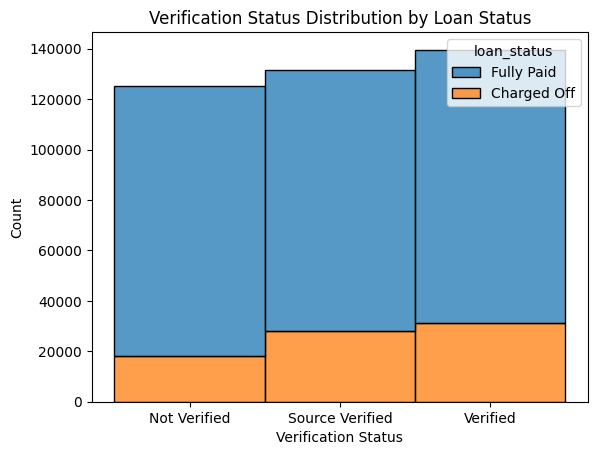

In [159]:
sns.histplot(data=df,x='verification_status',hue='loan_status',stat='count',multiple='stack')
plt.title("Verification Status Distribution by Loan Status")
plt.xlabel("Verification Status")
plt.ylabel("Count")
plt.show()

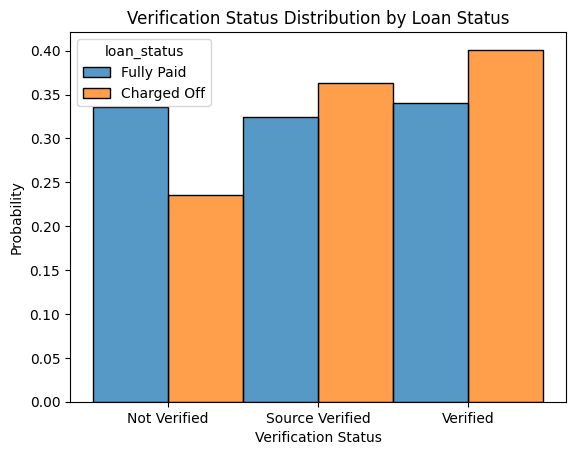

In [161]:
sns.histplot(data=df,x='verification_status',hue='loan_status',stat='probability',multiple='dodge',common_norm=False)
plt.title("Verification Status Distribution by Loan Status")
plt.xlabel("Verification Status")
plt.ylabel("Probability")
plt.show()


[**Answering the Hypothesis:**](#Verification-Status)

Charged Off fraction grows from


`Not Verified → Source Verified → Verified`

That's the counterintuitive result I flagged earlier: verified loans default more, not less.

It's not because verification causes default. It's that LoanTap verifies the applicants who already look risky — verification is triggered by risk. So it's a proxy for "we were worried about this one." Classic confounding: the variable correlates with default through a hidden third factor (underlying risk).

Which means `verification_status` is weak seperator of the target class.

#### Loan Status Vs Purpose

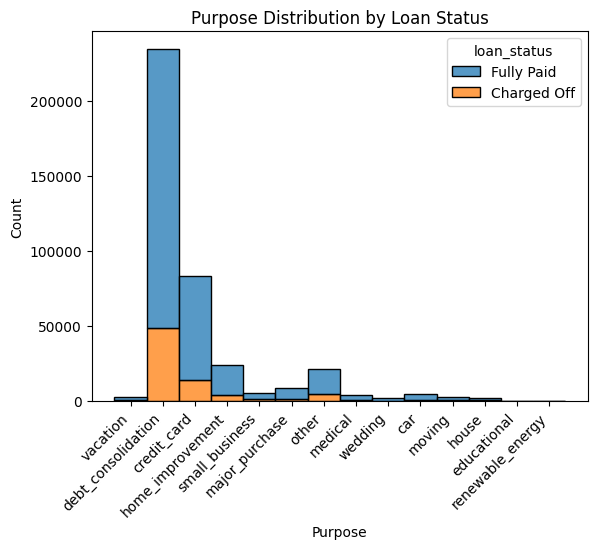

In [168]:
sns.histplot(data=df,x='purpose',hue='loan_status',stat='count',multiple='stack')
plt.title("Purpose Distribution by Loan Status")
plt.xlabel("Purpose")
plt.ylabel("Count")
plt.xticks(rotation=45, ha='right')
plt.show()

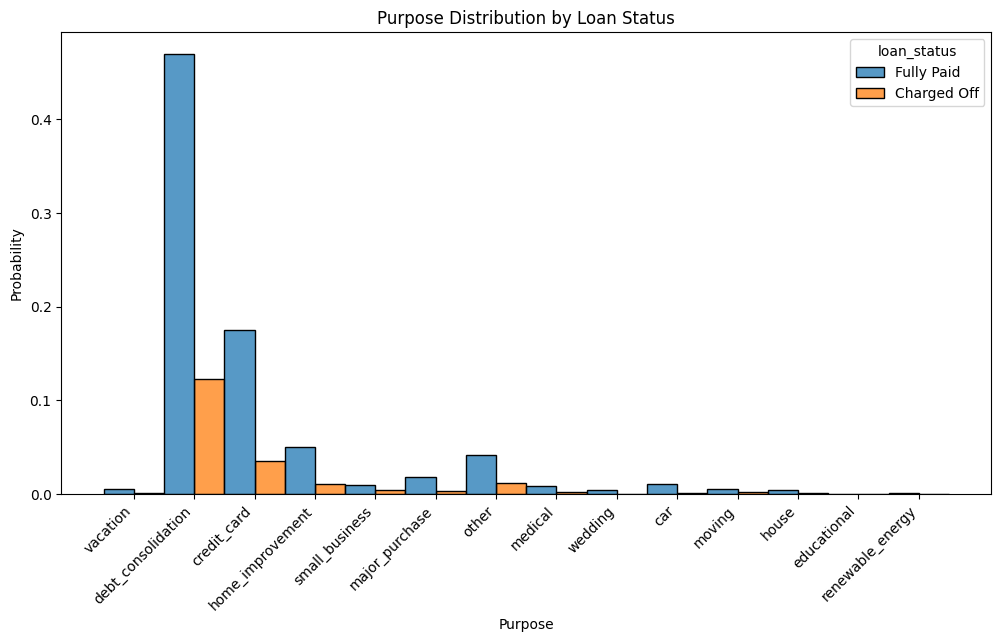

In [175]:
plt.figure(figsize=(12,6))
sns.histplot(data=df,x='purpose',hue='loan_status',stat='probability',multiple='dodge')
plt.title("Purpose Distribution by Loan Status")
plt.xlabel("Purpose")
plt.ylabel("Probability")
plt.xticks(rotation=45, ha='right')
plt.show()

Loan Status is dominated by `debt_consolidation` simply because that's the most common purpose. we can't see which purpose defaults more because every bar is swamped by base frequency.

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13],
 [Text(0, 0, 'wedding'),
  Text(1, 0, 'car'),
  Text(2, 0, 'educational'),
  Text(3, 0, 'major_purchase'),
  Text(4, 0, 'credit_card'),
  Text(5, 0, 'home_improvement'),
  Text(6, 0, 'vacation'),
  Text(7, 0, 'house'),
  Text(8, 0, 'debt_consolidation'),
  Text(9, 0, 'other'),
  Text(10, 0, 'medical'),
  Text(11, 0, 'renewable_energy'),
  Text(12, 0, 'moving'),
  Text(13, 0, 'small_business')])

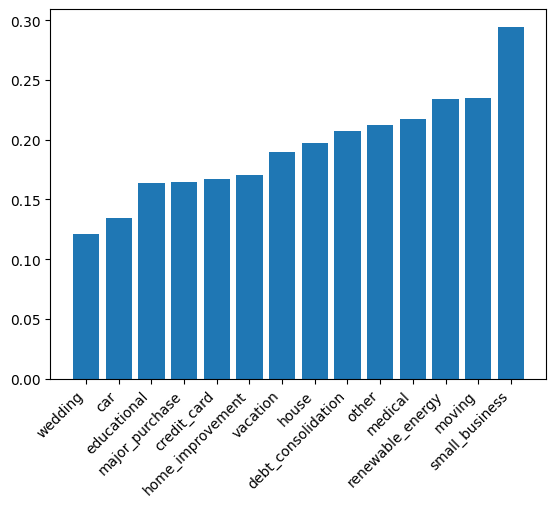

In [179]:
df['<0/1 target>'] = df['loan_status'].apply(lambda x: 1 if x == 'Charged Off' else 0)

plt.bar(df.groupby('purpose')['<0/1 target>'].mean().sort_values().index,df.groupby('purpose')['<0/1 target>'].mean().sort_values().values)
plt.xticks(rotation=45, ha='right')


- `purpose` default mean are mostly consolidate in the range 12-24.
- So, `purpose` is a mild predictor; small_business stands out as highest-risk, but most categories sit near the base rate.

#### Other Categorical features:

- `application_type` is mostly dominated by INDIVIDUAL which is 99%. So, we can ignore it in this section.
- `address` is high Cardinality.
- `earliest_cr_line` is not relevant for target analysis. It might be useful for other account related fetures.
- `title` can be ignored becuase we are analysing the purpose.
- `issue_d` is also not relevant since the new applican't will not have one.


### Summary of Target Class Vs Categorical feature analysis

- Loan Status Vs Loan Amount: Larger loan amounts show an accelerated risk of default, with a noticeable pile-up of charged-off loans shifting toward the maximum $40,000 cap.

- Loan Status Vs Grades: Default rates scale dramatically and monotonically as credit quality drops, rising from a low risk in Grade A to an exceptionally high risk (often over 40%) in Grade G.

- Loan Status Vs Employment Length: Employment length acts as a weak standalone predictor, as default rates remain relatively stable across different year brackets once a borrower is salaried.

- Loan Status Vs Term: Borrowers opting for a longer 60-month term carry a drastically higher probability of defaulting compared to those choosing a standard 36-month term.

- Loan Status Vs Home Ownership: Applicants who rent or have a mortgage show a higher baseline default risk compared to those who outright own their home.

- Loan Status Vs Verification Status: Surprisingly, "Verified" loans historically show a higher default rate, likely because lenders only enforce strict verification on fundamentally riskier.

- Loan Status Vs Purpose: While most loan purposes cluster near the baseline risk, applications for small business ventures stand out as the highest-risk segment in the portfolio.

#### Loan Status Vs Interest Rate

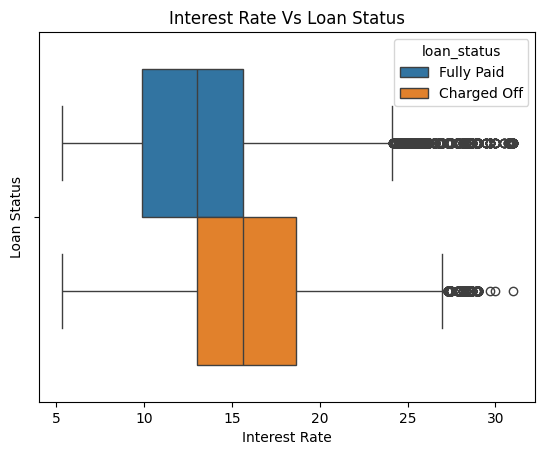

In [184]:
sns.boxplot(data=df,x='int_rate',hue='loan_status')
plt.title("Interest Rate Vs Loan Status")
plt.xlabel("Interest Rate")
plt.ylabel("Loan Status")
plt.show()

- The orange (Charged Off) box sits clearly to the right of blue (Fully Paid).
- Defaulters' median rate ~15.5% vs repayers' ~13%, and the whole orange distribution is shifted higher. Defaulters were charged higher interest rates.
- Because we knew risk with those applications were high during the interest rate calculation and Since the risk was high the default rate is also high. Just like the `verification_status` verified applicants. They were high risk applicant thats what triggered the verification.

## Correlation

Text(0.5, 1.0, 'Correlation Heatmap')

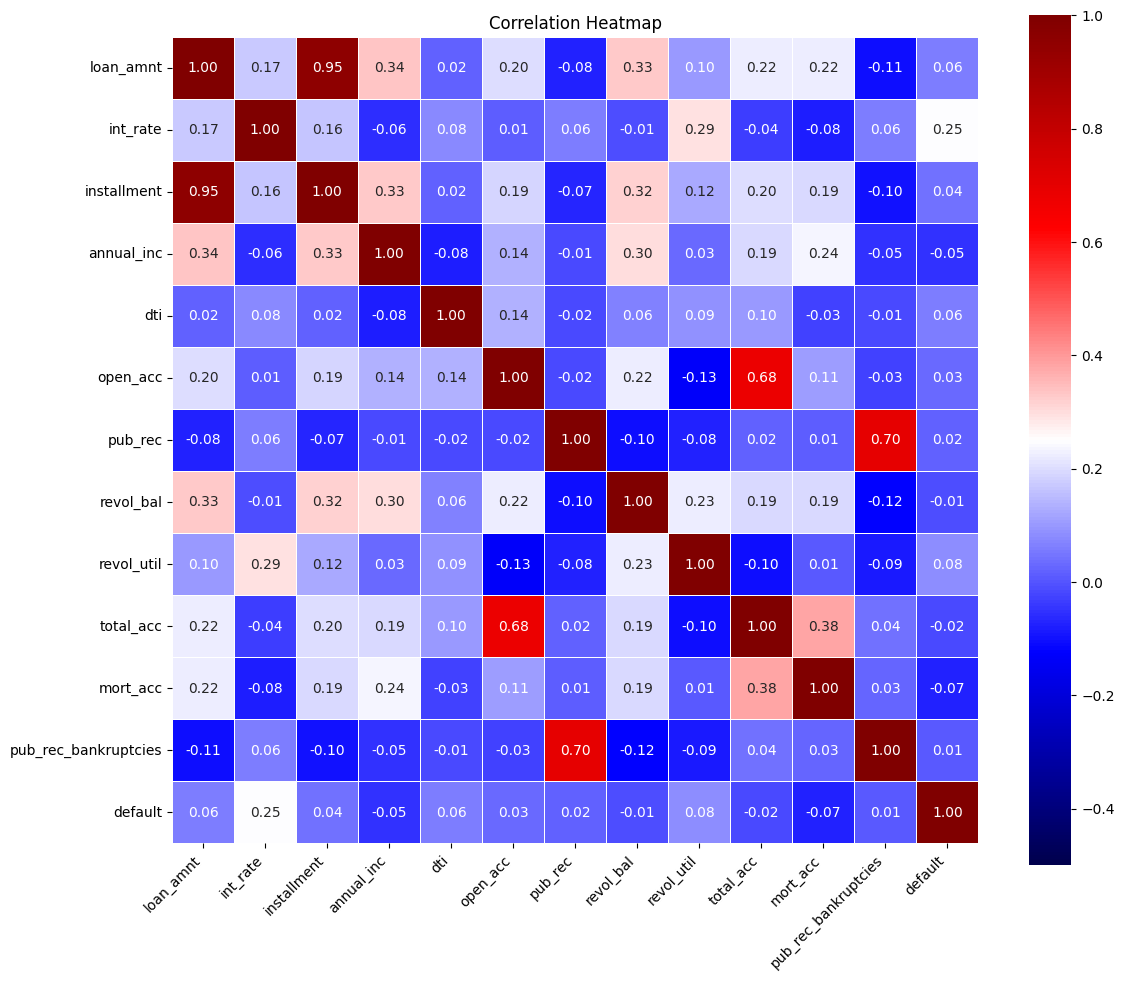

In [197]:
num_df = df.select_dtypes(exclude='object').drop(columns=['<0/1 target>'], errors='ignore')
corr_mat = num_df.corr()

plt.figure(figsize=(12,10))

sns.heatmap(corr_mat,annot=True,cmap='seismic',fmt='.2f',vmin=-0.5,vmax=1,linewidths=0.5,square=True)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.title("Correlation Heatmap")

**Multicollinearity Pairs:**

- loan_amnt and installment = 0.95

- pub_rec and pub_rec_bankrupcies = 0.7

- open_acc and total_acc = 0.68

It's because installment is calculated using loan_amnt and other two are a subet of the respective feature. So, we can drop one form each pair.

**Linear Correlation:**

The only meaningful linear correlation we have is `int_rate` 0.25 Which does not mean others are not related. This only reflects numeric features; the strongest predictors (grade, term) are categorical and excluded here. Low numeric correlation doesn't mean those features are useless It means the model will assess them.

**Heatmap Takeaway:**

Most numeric features are weakly correlated with each other and with default — good (low redundancy). The exceptions are three near-duplicate pairs (loan_amnt/installment, the two pub_rec fields, open_acc/total_acc), which will be deduplicated before modeling to avoid multicollinearity. Categorical predictors (grade, term) are stronger but not captured here.

### To Dos:

- [ ] Change the object to category dtype and `issue_d`,`earliest_cr_line` to datetime type.
- [ ] Look into feature eng of 'title'
- [ ] We can extract parts of address into new feats like city, country and zip code during feature engineering.
 -[ ] Check the trend b/w interest rate, loan amount
 - [ ] installment vs loan anount vs loan period
 - Annual income has 0 data
 - Compare total_acc and open_acc
 - Use mortgage , credit default, open acc metrics to find trends. MAybe new good features from these.
 - Which we have to resolve in the feature engineering section.
 - int_rate and grade both encode risk, they'll be correlated with each other

- dti outliars > 1000
- annual inc 0
-